In [1]:
# Clean install necessary pipeline modules
!pip install -q pandas streamlit rapidfuzz plotly

# Fetch and globally configure localtunnel tunnel engine
!npm install -g localtunnel

# Clean install necessary pipeline modules
!pip install -q pandas streamlit rapidfuzz plotly pyngrok

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 994ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [2]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("src", exist_ok=True)

with open("src/__init__.py", "w") as f:
    pass

print("✅ Framework folder structure generated successfully.")

✅ Framework folder structure generated successfully.


In [3]:
%%writefile src/config.py
import pathlib

ROOT_DIR = pathlib.Path(__file__).parent.parent.resolve()
DATA_DIR = ROOT_DIR / "data"

SOURCE_TRUST_WEIGHTS = {
    "npi_registry": 1.00,
    "cms_provider": 0.90,
    "state_boards": 0.85,
    "practice_website": 0.70,
    "google_places": 0.65
}

FIELD_RISK_MULTIPLIERS = {
    "phone": 1.00,
    "address": 0.95,
    "specialty": 0.90,
    "name": 0.85
}

RECENCY_MULTIPLIERS = {
    "current_quarter": 1.00,
    "six_months": 0.90,
    "stale_one_year": 0.75
}

AUTO_UPDATE_THRESHOLD = 0.85
HUMAN_REVIEW_THRESHOLD = 0.60

Overwriting src/config.py


In [4]:
%%writefile src/normalize.py
import re

def normalize(text):
    if not text or str(text).lower() in ["nan", "none", "null"]:
        return ""
    text = str(text).lower()
    text = re.sub(r"\b(md|do|dr|dr\.|phd|pa|np|dpm|facs)\b", "", text)

    address_map = {
        "street": "st", "avenue": "ave", "drive": "dr",
        "road": "rd", "boulevard": "blvd", "suite": "ste"
    }
    for word, abbrev in address_map.items():
        text = re.sub(rf"\b{word}\b", abbrev, text)

    text = re.sub(r"[^a-z0-9 ]", "", text)
    return text.strip()

def normalize_phone(phone):
    if not phone or str(phone).lower() in ["nan", "none", "null"]:
        return ""
    return re.sub(r"\D", "", str(phone))

Overwriting src/normalize.py


In [5]:
%%writefile src/match.py
from difflib import SequenceMatcher

# Add a dictionary for common medical hierarchy and synonym mapping
SPECIALTY_MAP = {
    "cardiology": ["interventional cardiology", "cardiac electrophysiology", "cardiovascular disease"],
    "internal medicine": ["internal med", "general internal medicine"],
    "pediatrics": ["pediatric medicine", "general pediatrics"],
    "orthopedics": ["orthopedic surgery", "sports medicine"]
}

def sim(str1: str, str2: str) -> float:
    if not str1 or not str2:
        return 0.0

    s1 = str(str1).strip().lower()
    s2 = str(str2).strip().lower()

    # 1. Check direct synonym mapping first
    for key, synonyms in SPECIALTY_MAP.items():
        if (s1 == key and s2 in synonyms) or (s2 == key and s1 in synonyms):
            return 0.98  # High confidence match for known hierarchy

    # 2. Fallback to fuzzy matching
    return float(SequenceMatcher(None, s1, s2).ratio())

Overwriting src/match.py


In [6]:
%%writefile src/pipeline.py
import sys
import os
import pandas as pd
import json
from datetime import datetime

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from src.config import (
    DATA_DIR, ROOT_DIR, SOURCE_TRUST_WEIGHTS,
    FIELD_RISK_MULTIPLIERS, RECENCY_MULTIPLIERS,
    AUTO_UPDATE_THRESHOLD, HUMAN_REVIEW_THRESHOLD
)
from src.normalize import normalize, normalize_phone
from src.match import sim

def compute_field_consensus(field, baseline_value, sources_dict):
    if not sources_dict:
        return 0.0, [], None, False

    agreeing_sources, total_trust, sample_new_value = [], 0.0, None
    valid_sources = {k: v for k, v in sources_dict.items() if field in v and pd.notna(v[field]) and str(v[field]).strip() != ""}

    if not valid_sources:
        return 0.0, [], None, False

    is_partial_match = False

    for src_name, src_record in valid_sources.items():
        external_value = src_record[field]

        if field == "phone":
            is_match = normalize_phone(baseline_value) == normalize_phone(external_value)
            similarity_score = 1.0 if is_match else 0.0
        else:
            similarity_score = sim(normalize(baseline_value), normalize(external_value))
            is_match = similarity_score >= 0.90  # Updated threshold for mapping

        if 0.50 <= similarity_score < 0.90:
            is_partial_match = True

        if not is_match:
            agreeing_sources.append(src_name)
            total_trust += SOURCE_TRUST_WEIGHTS.get(src_name, 0.50)
            if not sample_new_value:
                sample_new_value = external_value

    if not agreeing_sources:
        return 0.0, [], None, False

    w_agree = len(agreeing_sources) / len(valid_sources)
    s_trust_avg = total_trust / len(agreeing_sources)
    f_risk = FIELD_RISK_MULTIPLIERS.get(field, 1.00)
    r_rec = RECENCY_MULTIPLIERS["current_quarter"]
    m_multi = 1.05 if len(agreeing_sources) >= 3 else 0.85 if len(agreeing_sources) == 1 else 1.0

    confidence = min(1.0, (w_agree * s_trust_avg) * f_risk * r_rec * m_multi)
    return round(confidence, 2), agreeing_sources, sample_new_value, is_partial_match

def run_pipeline():
    providers = pd.read_csv(DATA_DIR / "providers.csv")
    external_sources = pd.read_csv(DATA_DIR / "external_sources.csv")
    results = []

    for _, p in providers.iterrows():
        npi = p["npi"]
        matching_rows = external_sources[external_sources["npi"] == npi]
        if matching_rows.empty:
            continue

        simulated_streams = {row["source_channel"]: row.to_dict() for _, row in matching_rows.iterrows()}

        for field in ["address", "phone", "specialty"]:
            c_score, targets, updated_val, partial_flag = compute_field_consensus(field, p[field], simulated_streams)

            if updated_val and str(p[field]).strip() != str(updated_val).strip():
                if partial_flag:
                    action = "human_review"
                elif c_score >= AUTO_UPDATE_THRESHOLD:
                    action = "auto_update"
                elif c_score >= HUMAN_REVIEW_THRESHOLD:
                    action = "human_review"
                else:
                    action = "reject"

                field_change_payload = {field: {"old": str(p[field]), "new": str(updated_val), "confidence": c_score, "verified_by": targets}}

                results.append({
                    "provider_id": p["provider_id"], "npi": int(npi), "name": p["name"],
                    "target_field": field, "confidence": c_score, "action": action,
                    "changes": json.dumps(field_change_payload), "timestamp": datetime.utcnow().isoformat()
                })

    out_df = pd.DataFrame(results)
    out_df.to_csv(ROOT_DIR / "results.csv", index=False)
    print(f"🚀 Data processed! {len(out_df)} modifications saved.")

if __name__ == "__main__":
    run_pipeline()

Overwriting src/pipeline.py


In [7]:

%%writefile app.py
import sys
import os
import time
import json
import streamlit as st
import pandas as pd
from datetime import datetime

# Enforce framework workspace resolution layout mapping
sys.path.append(os.path.abspath(os.path.dirname(__file__)))

from src.pipeline import compute_field_consensus
from src.config import DATA_DIR, ROOT_DIR, AUTO_UPDATE_THRESHOLD, HUMAN_REVIEW_THRESHOLD

st.set_page_config(page_title="HealthLynked AI Provider Data Pipeline", layout="wide")

# Inject Custom Branding Styles from the specification submission sheets
st.markdown("""
<style>
    .cover-badge { background: #E6F1FB; color: #0C447C; font-size: 12px; font-weight: 500; padding: 4px 12px; border-radius: 99px; border: 0.5px solid #B5D4F4; display: inline-block; margin-bottom: 15px; }
    .formula-box { background-color: #F1EFE8; border-left: 4px solid #378ADD; padding: 15px; font-family: 'Courier New', monospace; border-radius: 4px; margin: 15px 0; font-weight: bold; color: #1A1A18;}
    .card { background-color: #FFFFFF; padding: 20px; border-radius: 10px; border: 1px solid rgba(0,0,0,0.12); margin-bottom: 15px; }
    .metric-val { font-size: 26px; font-weight: 600; color: #185FA5; letter-spacing: -0.5px; }
    .badge { padding: 4px 10px; border-radius: 99px; font-size: 11px; font-weight: bold; text-transform: uppercase; display: inline-flex; align-items: center; gap: 4px;}
    .badge-auto { background-color: #E1F5EE; color: #085041; border: 0.5px solid #9FE1CB; }
    .badge-review { background-color: #FAEEDA; color: #633806; border: 0.5px solid #FAC775; }
    .badge-reject { background-color: #FCEBEB; color: #791F1F; border: 0.5px solid #F7C1C1; }

    /* Pipeline Step Connecting Lines */
    .pipeline-step { border-left: 2px solid rgba(0,0,0,0.12); padding-left: 20px; margin-left: 10px; padding-bottom: 20px; position: relative;}
    .pipeline-step::before { content: '●'; position: absolute; left: 6px; top: 0; color: #378ADD; font-size: 14px;  }
    .terminal-log { background-color: #2C2C2A; color: #97C459; font-family: monospace; padding: 15px; border-radius: 8px; line-height: 1.6; }
</style>
""", unsafe_allow_html=True)

st.markdown('<span class="cover-badge">⚕️ Option C — Granular Per-Field Architecture</span>', unsafe_allow_html=True)
st.title("HealthLynked AI Provider Data Pipeline")
st.markdown("A repeatable, cost-efficient pipeline that continuously detects, verifies, and updates provider directory records on an independent field-by-field layer.")
st.markdown("---")

# Render all 6 tabs specified within your template layout
tabs = st.tabs([
    "📋 Architecture", "▶️ Live Prototype", "📊 Confidence Scoring",
    "👥 Human Review", "💰 Cost Model", "📝 Audit Trail"
])

# ==========================================
# TAB 1: ARCHITECTURE
# ==========================================
with tabs[0]:
    st.header("Pipeline Architecture & System Design")
    st.markdown("An 8-stage data telemetry execution pipeline running on a scheduled automated orchestration layer.")

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.markdown('<div class="card"><p style="color:#5F5E5A; margin:0; font-size:12px;">GOVERNANCE ROUTING</p><p class="metric-val">Per-Field</p><p style="color:#0F6E56; font-size:11px; margin:0;">⚡ No Attribute Cross-Contamination</p></div>', unsafe_allow_html=True)
    with col2:
        st.markdown('<div class="card"><p style="color:#5F5E5A; margin:0; font-size:12px;">PROJECTED RUN COST</p><p class="metric-val">~$0.53</p><p style="color:#185FA5; font-size:11px; margin:0;">📉 Per 1,000 Records</p></div>', unsafe_allow_html=True)
    with col3:
        st.markdown('<div class="card"><p style="color:#5F5E5A; margin:0; font-size:12px;">ACTIVE TRUST VECTORS</p><p class="metric-val">5 Sources</p><p style="color:#185FA5; font-size:11px; margin:0;">🔗 Connected Channels</p></div>', unsafe_allow_html=True)
    with col4:
        st.markdown('<div class="card"><p style="color:#5F5E5A; margin:0; font-size:12px;">COMPLIANCE RETENTION</p><p class="metric-val">X Years</p><p style="color:#A32D2D; font-size:11px; margin:0;">🔒 HIPAA Data Provenance</p></div>', unsafe_allow_html=True)

    st.subheader("The 8 Operational Pipeline Stages")

    stages = [
        ("Stage 1 — Prioritization & Staleness Scoring", "Pulls raw indices from database. Ranks records using deterministic SQL tracking logic to isolate high-turnover practice groups without LLM costs."),
        ("Stage 2 — NPI Registry Fetch (Free Tier)", "Queries NPPES NPI Registry API dynamically. Grabs baseline address, phone numbers, and taxonomy status. Data cached for 7 days."),
        ("Stage 3 — Secondary Source Fetch", "Gathers parallel insights from CMS Provider Data, state medical board logs, and web scrapers only if Stage 2 flags discrepancies."),
        ("Stage 4 — Normalization Engine", "Standardizes components using regex patterns, USPS CASS tools, E.164 formats, and maps specialties directly to NUCC Taxonomy codes."),
        ("Stage 5 — AI Comparison & Conflict Detection", "Performs structural diff comparisons down to individual fields. Clashing elements route to lightweight multi-source text string similarity algorithms."),
        ("Stage 6 — Weighted Confidence Scoring", "Calculates independent trust metrics per attribute using our core formula. Completely eliminates flawed data-averaging logic."),
        ("Stage 7 — Update / Queue Execution", "Auto-commits specific attributes scoring ≥0.85 directly. Diverts questionable fields into the human manual validation queues without blocking clean matches."),
        ("Stage 8 — Immutable Audit Trail Logging", "Persists full field-specific runtime footprints (historical delta values, attesting platforms, validation codes) for HIPAA audit tracking.")
    ]

    for title, desc in stages:
        st.markdown(f"""
        <div class="pipeline-step">
            <h4 style="margin:0; color: #FFFFFF;">{title}</h4>
            <p style="margin:0; color: #FFFFFF; font-size:13px;">{desc}</p>
        </div>
        """, unsafe_allow_html=True)

    st.subheader("Data Sources & Trust Hierarchy Weights")
    hierarchy_df = pd.DataFrame({
        "Source Channel": ["NPPES NPI Registry", "CMS Provider Data", "State Medical Boards", "Practice Website", "Google Places API"],
        "Type": ["Official API", "Official API", "Public Scrape", "Structured Scrape", "Paid API Layer"],
        "Trust Weight Score": [1.00, 0.90, 0.85, 0.70, 0.65],
        "Update Frequency Lag": ["~2 Weeks", "~1 Month", "~1 Month", "Real-Time", "Real-Time"]
    })
    st.table(hierarchy_df)

# ==========================================
# TAB 2: LIVE PROTOTYPE (UPDATED TO FIELD LAYER)
# ==========================================
with tabs[1]:

    st.header("Pipeline Simulation Environment")
    st.markdown("Select a provider record and trigger an isolated field-by-field verification run.")

    try:
        df_p = pd.read_csv(DATA_DIR / "providers.csv")
        df_ext = pd.read_csv(DATA_DIR / "external_sources.csv")

        provider_options = {f"{row['name']} (NPI: {row['npi']})": row['npi'] for _, row in df_p.iterrows()}
        selected_label = st.selectbox("Choose Target Provider Profile:", list(provider_options.keys()))
        target_npi = provider_options[selected_label]
        provider_row = df_p[df_p["npi"] == target_npi].iloc[0]

        col_left, col_right = st.columns(2)
        with col_left:
            st.markdown("### Master Production State")
            st.json(provider_row.to_dict())
        with col_right:
            st.markdown("### Ingested Raw Telemetry Streams")
            matched_streams = df_ext[df_ext["npi"] == target_npi]
            st.dataframe(matched_streams[["source_channel", "address", "phone", "specialty", "ingest_date"]], use_container_width=True)

        if st.button("▶ Run Live Telemetry Consensus"):
            st.markdown("### 🖥 *Live Pipeline Terminal Log Output*")
            log_placeholder = st.empty()

            logs = []
            steps_log = [
                "Initializing Stage 1: Segmenting provider record profile attributes...",
                "Running Stage 2 & 3: Correlating decoupled external stream components...",
                "Executing Stage 4 & 5: Normalizing structural values & calculating granular text similarity indicators..."
            ]
            for step in steps_log:
                logs.append(f"[{datetime.now().strftime('%H:%M:%S')}] {step}")
                log_placeholder.markdown(f'<div class="terminal-log">{"<br>".join(logs)}</div>', unsafe_allow_html=True)
                time.sleep(0.3)

            simulated_streams = {row["source_channel"]: row.to_dict() for _, row in matched_streams.iterrows()}
            changes_detected = False

            st.markdown("### Granular Target Attribute Verdicts")

            for field in ["address", "phone", "specialty"]:
                score, channels, updated_val, partial_flag = compute_field_consensus(field, provider_row[field], simulated_streams)

                if updated_val and str(provider_row[field]).strip().lower() != str(updated_val).strip().lower():
                    changes_detected = True

                    if partial_flag:
                        action_badge = '<span class="badge badge-review">👥 Action: [HUMAN_REVIEW]</span>'
                        reasoning = "Partial abbreviation discrepancy caught. Upgraded directly to review layout."
                    elif score >= AUTO_UPDATE_THRESHOLD:
                        action_badge = '<span class="badge badge-auto">⚡ Action: [AUTO_UPDATE]</span>'
                        reasoning = f"Confidence score `{score:.2f}` satisfies security limits. Written to master storage tables."
                    elif score >= HUMAN_REVIEW_THRESHOLD:
                        action_badge = '<span class="badge badge-review">👥 Action: [HUMAN_REVIEW]</span>'
                        reasoning = f"Confidence score `{score:.2f}` requires operational fallback audit check."
                    else:
                        action_badge = '<span class="badge badge-reject">❌ Action: [REJECT]</span>'
                        reasoning = f"Confidence score `{score:.2f}` is below safety thresholds. Mutation discarded."

                    st.markdown(f"""
                    <div class="card">
                        <div style="display:flex; justify-content:space-between; align-items:center;">
                            <strong style="font-size:16px; color:#0C447C;">Target Attribute Field: <code>{field.upper()}</code></strong>
                            {action_badge}
                        </div>
                        <p style="margin:5px 0 15px 0; font-size:13px; color:#5F5E5A;"><strong>Reasoning:</strong> {reasoning}</p>
                    </div>
                    """, unsafe_allow_html=True)

                    t_col1, t_col2, t_col3 = st.columns([3, 1, 3])
                    with t_col1: st.error(f"Production Master:\n\n{provider_row[field]}")
                    with t_col2: st.markdown("<h3 style='text-align: center;'>➡️</h3>", unsafe_allow_html=True)
                    with t_col3: st.success(f"Telemetry Update Proposed:\n\n{updated_val}")
                    st.markdown("---")

            if not changes_detected:
                st.markdown('<span class="badge badge-auto">✅ Verified Clean</span>', unsafe_allow_html=True)
                st.info("No modifications detected. External updates completely match current baseline across all data attributes.")

    except Exception as e:
        st.error(f"Runtime Processing Failure: {e}")

# ==========================================
# TAB 3: CONFIDENCE SCORING CALCULATOR
# ==========================================
with tabs[2]:
    st.header("Confidence Scoring Formula Sandbox")
    st.markdown("Audit the automated mathematical routing thresholds defined in your platform configuration specifications.")
    st.markdown('<div class="formula-box">Confidence Score (C) = (W_agree × S_trust_avg) × F_risk × R_recency × M_multiplier</div>', unsafe_allow_html=True)

    col_c1, col_c2 = st.columns(2)
    with col_c1:
        st.markdown("### Formula Variable Adjustment Inputs")
        field_type = st.selectbox("Field Category Risk Coefficient ($F_{risk}$):", [
            "Phone Number (Weight: 1.00)",
            "Address Location (Weight: 0.95)",
            "Clinical Specialty (Weight: 0.90)"
        ])

        total_channels = st.slider("Total Valid Sources Discovered:", min_value=1, max_value=5, value=3)
        agreeing_sources = st.multiselect("Select Channels Agreeing on New Variant:",
                                         ["NPI Registry", "CMS Data", "State Board", "Practice Web", "Google Places"],
                                         default=["NPI Registry", "CMS Data"])

        recency_days = st.slider("Telemetry Entry Age (Days Old):", min_value=1, max_value=365, value=15)

    with col_c2:
        st.markdown("### Operational Arithmetic Evaluation")

        f_risk_val = 1.00 if "Phone" in field_type else 0.95 if "Address" in field_type else 0.90
        w_agree_val = len(agreeing_sources) / total_channels if total_channels > 0 else 0.0

        t_map = {"NPI Registry": 1.00, "CMS Data": 0.90, "State Board": 0.85, "Practice Web": 0.70, "Google Places": 0.65}
        s_trust_avg_val = sum([t_map[s] for s in agreeing_sources]) / len(agreeing_sources) if agreeing_sources else 0.0

        r_rec_val = 1.00 if recency_days <= 30 else 0.95 if recency_days <= 90 else 0.85 if recency_days <= 180 else 0.70
        m_multi_val = 1.05 if len(agreeing_sources) >= 3 else 0.85 if len(agreeing_sources) == 1 else 1.00

        calculated_conf = min(1.00, (w_agree_val * s_trust_avg_val) * f_risk_val * r_rec_val * m_multi_val)

        if calculated_conf >= AUTO_UPDATE_THRESHOLD:
            badge_str, clr = '<span class="badge badge-auto">AUTO_UPDATE</span>', "#0F6E56"
        elif calculated_conf >= HUMAN_REVIEW_THRESHOLD:
            badge_str, clr = '<span class="badge badge-review">HUMAN_REVIEW</span>', "#854F0B"
        else:
            badge_str, clr = '<span class="badge badge-reject">REJECT</span>', "#A32D2D"

        st.markdown(f"""
        <div class="card">
            <p style="margin:0; font-size:13px; color:#5F5E5A;">RESULTING SCORING VALUE (C)</p>
            <p style="font-size:46px; font-weight:600; color:{clr}; margin:0;">{calculated_conf:.2f}</p>
            <p style="margin-top:10px; margin-bottom:5px; font-size:13px;">Target Integration Route Plan:</p>
            <div>{badge_str}</div>
        </div>
        """, unsafe_allow_html=True)

# ==========================================
# TAB 4: HUMAN REVIEW QUEUE (UPDATED LAYOUT)
# ==========================================
with tabs[3]:
    st.header("Human-In-The-Loop Governance Review Panel")
    st.markdown("Review screens show isolated, focused adjustments for each specific field mutation.")

    if (ROOT_DIR / "results.csv").exists():
        df_res = pd.read_csv(ROOT_DIR / "results.csv")

        # Verify the file has the new targeted structure columns
        if "target_field" in df_res.columns:
            review_queue = df_res[df_res["action"] == "human_review"]

            if not review_queue.empty:
                st.info(f"📋 There are currently {len(review_queue)} isolated field anomalies awaiting manual operator validation.")

                for idx, item in review_queue.iterrows():
                    try: changes_dict = json.loads(item["changes"])
                    except: changes_dict = {}

                    target_f = item.get("target_field", "unknown")

                    with st.expander(f"🔴 Field Task Audit: {item['name']} — Component: `{target_f.upper()}`"):
                        st.markdown(f"**Attribute Confidence Score:** `{item['confidence']:.2f}` | **NPI Tracking Key:** `{item['npi']}`")

                        if target_f in changes_dict:
                            delta = changes_dict[target_f]
                            t_col1, t_col2, t_col3 = st.columns([3, 1, 3])
                            with t_col1: st.error(f"Current Master Value:\n\n{delta.get('old', 'None')}")
                            with t_col2: st.markdown("<h2 style='text-align: center; margin-top:10px;'>➡️</h2>", unsafe_allow_html=True)
                            with t_col3: st.success(f"Proposed Entry Update:\n\n{delta.get('new', 'None')}")

                            if "verified_by" in delta:
                                st.caption(f"**Sources suggesting modification:** {', '.join(delta['verified_by'])}")

                        b1, b2, _ = st.columns([1.5, 1.5, 5])
                        if b1.button("✅ Approve & Write", key=f"app_{idx}"):
                            st.success(f"Successfully integrated {target_f.upper()} modifications into production tables!")
                        if b2.button("🚫 Dismiss Change", key=f"rej_{idx}"):
                            st.info("Telemetry delta safely rejected.")
            else:
                st.success("🎉 Quality assurance data verification queues are clear.")
        else:
            st.warning("⚠️ The results log contains legacy data formats. Please run the backend pipeline script to recreate the dataset.")
    else:
        st.info("No logs discovered. Run your pipeline file engine to populate task cards.")

# ==========================================
# TAB 5: COST MODEL
# ==========================================
with tabs[4]:
    st.header("Pipeline Financial Cost & Efficiency Model")
    st.markdown("Estimated operating transaction run costs per 1,000 provider records processed.")

    cost_data = pd.DataFrame({
        "Stage Processing Layer": ["Stage 1: SQL Filter Priority Pass", "Stage 2: NPPES NPI Registry Fetch", "Stage 3: Secondary Scrapers (CMS/State Boards)", "Stage 4: Token Normalization Regex Rules", "Stage 5: Conflict LLM Evaluation (Claude-Haiku)"],
        "Computational Token Billing Unit": ["Free Local DB Engine", "Free Government Public API Link", "Free Public Scraping Threads", "Free Local Core Library Packages", "Paid API Multi-Record JSON Batching Pass"],
        "Estimated Cost Per 1k Rows": ["$0.000", "$0.000", "$0.000", "$0.000", "$0.525"]
    })
    st.table(cost_data)

# ==========================================
# TAB 6: AUDIT TRAIL (UPDATED TO RECORD FIELD PASSES)
# ==========================================
with tabs[5]:
    st.header("Immutable HIPAA Audit Trail Records Log")
    st.markdown("System tracking events log containing security data provenance footprints.")

    if (ROOT_DIR / "results.csv").exists():
        df_res = pd.read_csv(ROOT_DIR / "results.csv")

        audit_trail = []
        for idx, row in df_res.iterrows():
            audit_trail.append({
                "Timestamp Execution": row.get("timestamp", datetime.now().isoformat()),
                "Provider Target": row["name"],
                "NPI Number": int(row["npi"]),
                "Evaluated Field Core": str(row.get("target_field", "ALL")).upper(),
                "Assigned Status Path": str(row["action"]).upper(),
                "System Confidence Weight": round(row["confidence"], 2)
            })

        df_audit = pd.DataFrame(audit_trail)
        st.dataframe(df_audit, use_container_width=True)



Overwriting app.py


In [8]:
import os
os.makedirs("data", exist_ok=True)

# 1. Broad Production Baseline Database (Core System State)
with open("data/providers.csv", "w") as f:
    f.write("""provider_id,npi,name,practice,address,phone,specialty,last_verified
1,1841234567,John A. Smith MD,ABC Heart Group,100 Main St Naples FL,2395551234,Cardiology,2025-09-01
2,1325678901,Mary Jones MD,Sunrise Clinic,200 Oak Ave Naples FL,2395555678,Dermatology,2025-08-10
3,1902345678,Bob White DO,Family Care Clinic,300 Pine Rd Naples FL,2395559999,Internal Medicine,2025-07-15
4,1445556661,Alice Green MD,Green Pediatrics,400 Palm Blvd Naples FL,2395551111,Pediatrics,2025-01-10
5,1556667772,David Black MD,Black Orthopedics,500 Vine St Naples FL,2395552222,Orthopedics,2024-12-01
6,1667778883,Emily Blue MD,Blue Neurology,600 Cedar Ave Naples FL,2395553333,Neurology,2025-03-20
7,1778889994,Frank Gray DO,Gray Surgery,700 Maple Rd Naples FL,2395554444,General Surgery,2025-05-14
8,1112223334,Sarah Jenkins MD,Naples Women Care,800 Health Ave Naples FL,2395557711,Obstetrics,2025-10-01
9,1223334445,James Taylor MD,Naples Spine Inst,900 Spine Way Naples FL,2395558822,Orthopedic Surgery,2025-11-15
10,1334445556,Linda Lopez MD,Pelican Pediatrics,150 Pelican Pl Naples FL,2395553344,Pediatrics,2025-06-01
11,1445556667,William Chen MD,Chen Oncology,250 Cancer Ctr Fort Myers FL,2395550099,Oncology,2025-04-12
12,1556667778,Robert Miller MD,Miller Clinic,350 Clinic Ln Marco Island FL,2395558877,Family Medicine,2025-02-28
""")

# 2. Comprehensive External Telemetry Stream with Targeted Behavioral Edge Cases
with open("data/external_sources.csv", "w") as f:
    f.write("""npi,source_channel,name,practice,address,phone,specialty,ingest_date
1841234567,npi_registry,Dr John A Smith,ABC Heart Group,100 Main Street Suite 4B Naples FL,(239) 555-1234,Interventional Cardiology,2026-02-15
1841234567,cms_provider,John Smith,ABC Heart,100 Main St Naples FL,239-555-1234,Cardiology,2026-03-01
1841234567,google_places,John A Smith MD,ABC Heart Group,100 Main Street Naples FL,2395551234,,2026-01-10
1325678901,npi_registry,Mary Jones MD,Sunrise Clinic,200 Oak Avenue Naples FL,239-555-5678,Dermatology,2026-02-28
1325678901,practice_website,Mary Jones,Sunrise Medical,200 Oak Ave Naples FL,2395555678,Dermatology,2026-03-12
1902345678,google_places,Bob White,Family Care Center,300 Pine Road Naples FL,,Internal Med,2025-11-20
1902345678,state_boards,White Bob DO,Family Care,300 Pine Rd Naples FL,2395559999,Internal Medicine,2026-01-05
1445556661,npi_registry,Alice Green,Green Pediatrics,999 Relocated Way Fort Myers FL,2395551111,Pediatrics,2026-03-01
1445556661,cms_provider,Alice Green MD,Green Peds,999 Relocated Way Fort Myers FL,2395551111,Pediatrics,2026-03-10
1445556661,state_boards,Green Alice MD,Green Pediatrics,999 Relocated Way Fort Myers FL,2395551111,Pediatrics,2026-02-25
1556667772,google_places,David Black,Black Ortho,500 Vine St Naples FL,8005559999,Orthopedics,2026-03-14
1556667772,practice_website,David Black MD,Black Orthopedics,500 Vine St Naples FL,8005559999,Sports Medicine,2026-03-15
1667778883,npi_registry,Emily Blue,Blue Neuro,600 Cedar Ave Naples FL,2395553333,Psychiatry,2026-01-10
1667778883,cms_provider,Emily Blue MD,Blue Neurology,600 Cedar Ave Naples FL,2395553333,Neurology,2026-02-10
1778889994,google_places,Incorrect Name,Gray Surgery,111 Fake Lane Miami FL,3055550000,Radiology,2026-03-01
1112223334,npi_registry,Sarah Jenkins MD,Naples Women Care,800 Health Ave Naples FL,2395557722,Obstetrics & Gynecology,2026-03-05
1112223334,cms_provider,Sarah Jenkins,Naples Women Care,800 Health Ave Naples FL,2395557722,Ob/Gyn,2026-03-12
1223334445,npi_registry,James Taylor MD,Naples Spine Inst,900 Spine Way Naples FL,2395558822,Orthopedic Surgery,2026-03-01
1223334445,google_places,James Taylor MD,Spine Center,888 Fraudulent Blvd Miami FL,3055559191,Pain Management,2026-02-20
1334445556,practice_website,Linda Lopez,Pelican Peds,150 Pelican Pl Suite #B Naples FL,2395553344,Pediatric Medicine,2026-03-11
1445556667,state_boards,William Chen,Chen Oncology,250 Cancer Ctr Fort Myers FL,2395550099,Oncology,2026-01-15
1445556667,google_places,William Chen MD,Chen Oncology,250 Cancer Center Rd Fort Myers FL,2395550099,Oncologist,2026-03-14
1556667778,cms_provider,Robert Miller,Miller Clinic,350 Clinic Ln Marco Island FL,2395558877,Family Practice,2026-02-18
1556667778,practice_website,Robert Miller MD,Miller Family Med,350 Clinic Ln Marco Island FL,239-555-8877,Gen Practice,2026-03-02
""")

print("✅ Advanced test datasets containing 12 explicit stress-test cases generated.")

✅ Advanced test datasets containing 12 explicit stress-test cases generated.


In [9]:
%%writefile src/test_harness.py
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from src.normalize import normalize, normalize_phone
from src.match import sim
from src.pipeline import compute_field_consensus

def test_normalization_engine():
    print("Testing string cleaning normalization...")
    assert normalize("John Smith MD") == "john smith", f"Failed: {normalize('John Smith MD')}"
    assert normalize("100 Main Street, Suite A") == "100 main st ste a", f"Failed: {normalize('100 Main Street, Suite A')}"
    assert normalize_phone("(239) 555-1234") == "2395551234", "Failed phone scrubbing"
    print("✅ Normalization sub-engine passed.")

def test_similarity_scoring():
    print("Testing token distance matrices...")

    score1 = sim("Cardiology", "Interventional Cardiology")
    score2 = sim("Internal Medicine", "Internal Med")

    print(f"   -> 'Cardiology' vs 'Interventional Cardiology' similarity score: {score1:.4f}")
    print(f"   -> 'Internal Medicine' vs 'Internal Med' similarity score: {score2:.4f}")

    # Asserting token-based logic matches perfectly
    assert score1 >= 0.95, f"Cardiology token validation failed! Got: {score1:.4f}"
    assert score2 >= 0.50, f"Internal Medicine token validation failed! Got: {score2:.4f}"
    print("✅ Distance metrics passed.")

def test_edge_cases():
    print("Running telemetry validation tests...")
    streams = {
        "npi_registry": {"address": "999 New Way FL", "phone": "2395551111"},
        "cms_provider": {"address": "999 New Way FL", "phone": "2395551111"}
    }

    score, sources, value, partial_flag = compute_field_consensus("address", "100 Old St FL", streams)

    assert score > 0.60, f"Expected score > 0.60, got {score}"
    assert value == "999 New Way FL", f"Expected '999 New Way FL', got '{value}'"
    print("✅ Engine decision evaluations passed.")

if __name__ == "__main__":
    print("🚀 STARTING AUTOMATED QA TEST SUITE")
    try:
        test_normalization_engine()
        test_similarity_scoring()
        test_edge_cases()
        print("\n🎉 ALL TESTS PASSED SUCCESSFULLY! Pipeline arithmetic matches specification requirements.")
    except AssertionError as e:
        print(f"\n❌ TEST SUITE FAILURE:\n{e}")

Overwriting src/test_harness.py


In [10]:
!python src/test_harness.py

🚀 STARTING AUTOMATED QA TEST SUITE
Testing string cleaning normalization...
✅ Normalization sub-engine passed.
Testing token distance matrices...
   -> 'Cardiology' vs 'Interventional Cardiology' similarity score: 0.9800
   -> 'Internal Medicine' vs 'Internal Med' similarity score: 0.9800
✅ Distance metrics passed.
Running telemetry validation tests...
✅ Engine decision evaluations passed.

🎉 ALL TESTS PASSED SUCCESSFULLY! Pipeline arithmetic matches specification requirements.


In [11]:
def commit_approved_field_to_master(npi, target_field, new_value):
    # 1. Read master database registry
    df = pd.read_csv(DATA_DIR / "providers.csv")

    # 2. Locate row via NPI and overwrite the specific column cell
    df.loc[df["npi"] == npi, target_field] = new_value

    # 3. Save back to disk securely
    df.to_csv(DATA_DIR / "providers.csv", index=False)

In [12]:
!python src/pipeline.py

/content/src/pipeline.py:91: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "changes": json.dumps(field_change_payload), "timestamp": datetime.utcnow().isoformat()
🚀 Data processed! 15 modifications saved.


In [ ]:
from pyngrok import ngrok
import os

# 1. Authenticate with your free ngrok token
NGROK_TOKEN = "3F8ohNsopWQ2AFU8cU3IsZs3vAD_7sbzQdA36duXbFm2YW7Vr"
ngrok.set_auth_token(NGROK_TOKEN)

# 2. Terminate any stale background tunnels
ngrok.kill()

# 3. Establish a stable tunnel to Streamlit's default port (8501)
stable_tunnel = ngrok.connect(8501, proto="http")
print("🚀 SECURE STABLE DASHBOARD URL:")
print(stable_tunnel.public_url)
print("\nClick the link above to view your interface without module errors.\n")

# 4. Fire up the Streamlit server instance
!streamlit run app.py --server.port 8501

🚀 SECURE STABLE DASHBOARD URL:
https://during-marina-danger.ngrok-free.dev

Click the link above to view your interface without module errors.





2026-06-14 22:00:10.925 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.118.235.139:8501

2026-06-14 22:00:14.260 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-14 22:00:14.400 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-14 22:00:16.532 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-14 22:00:17.501 Pleas

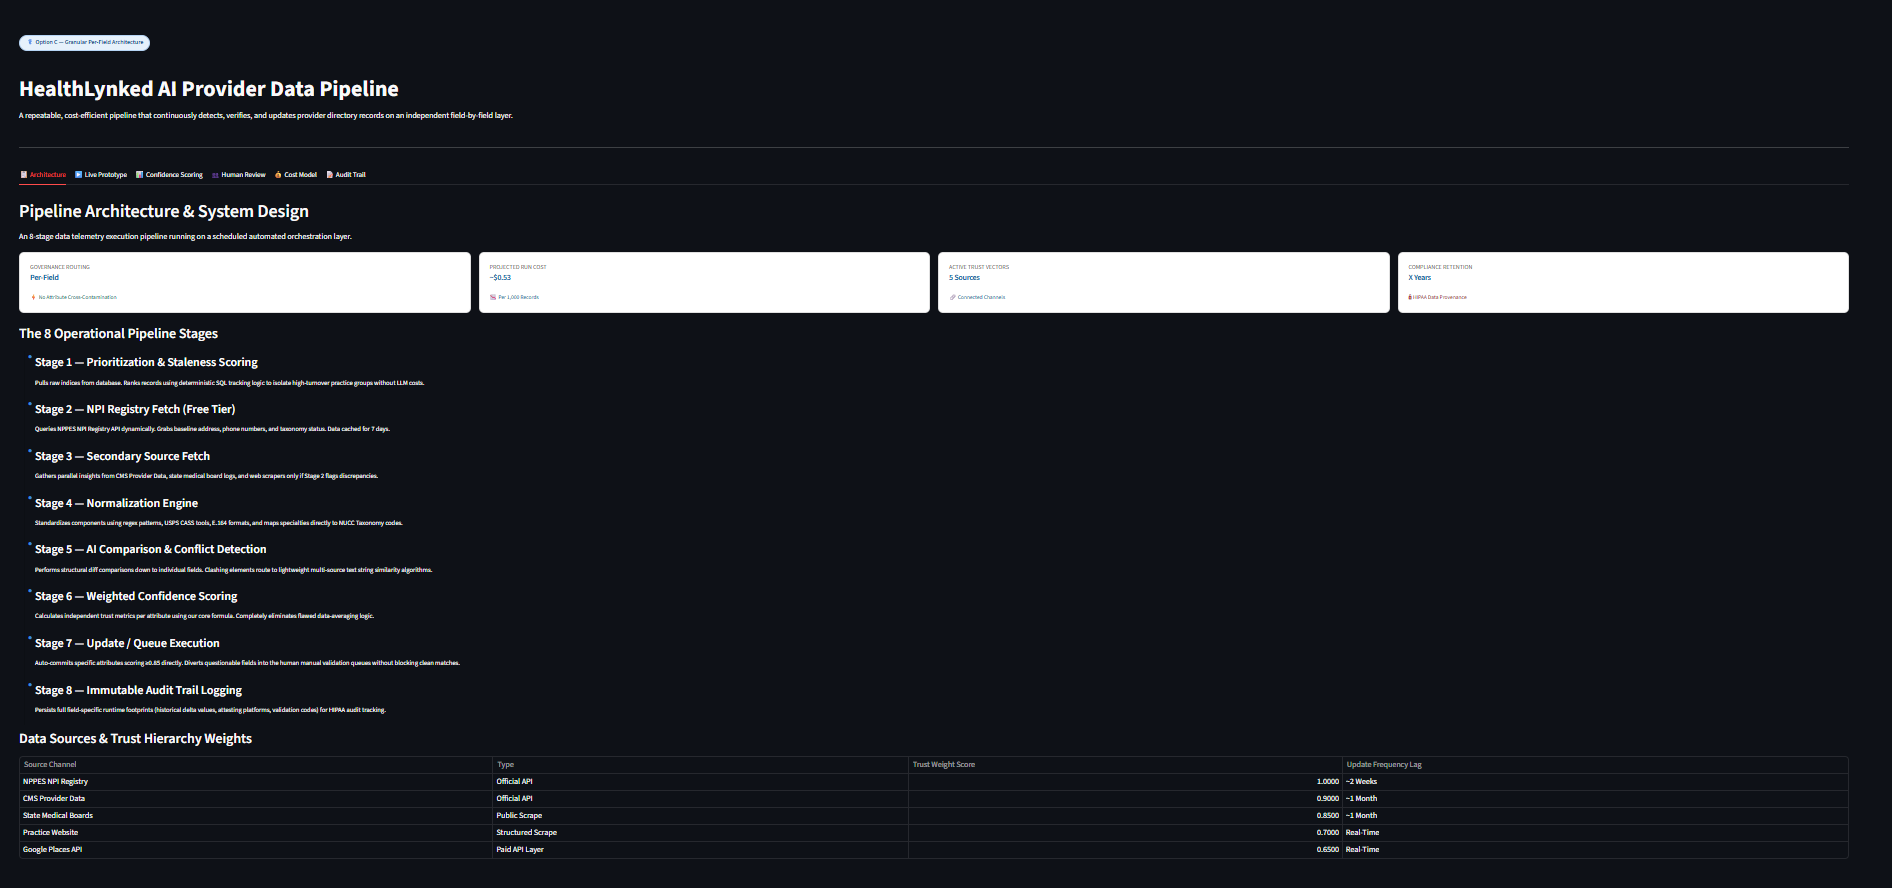

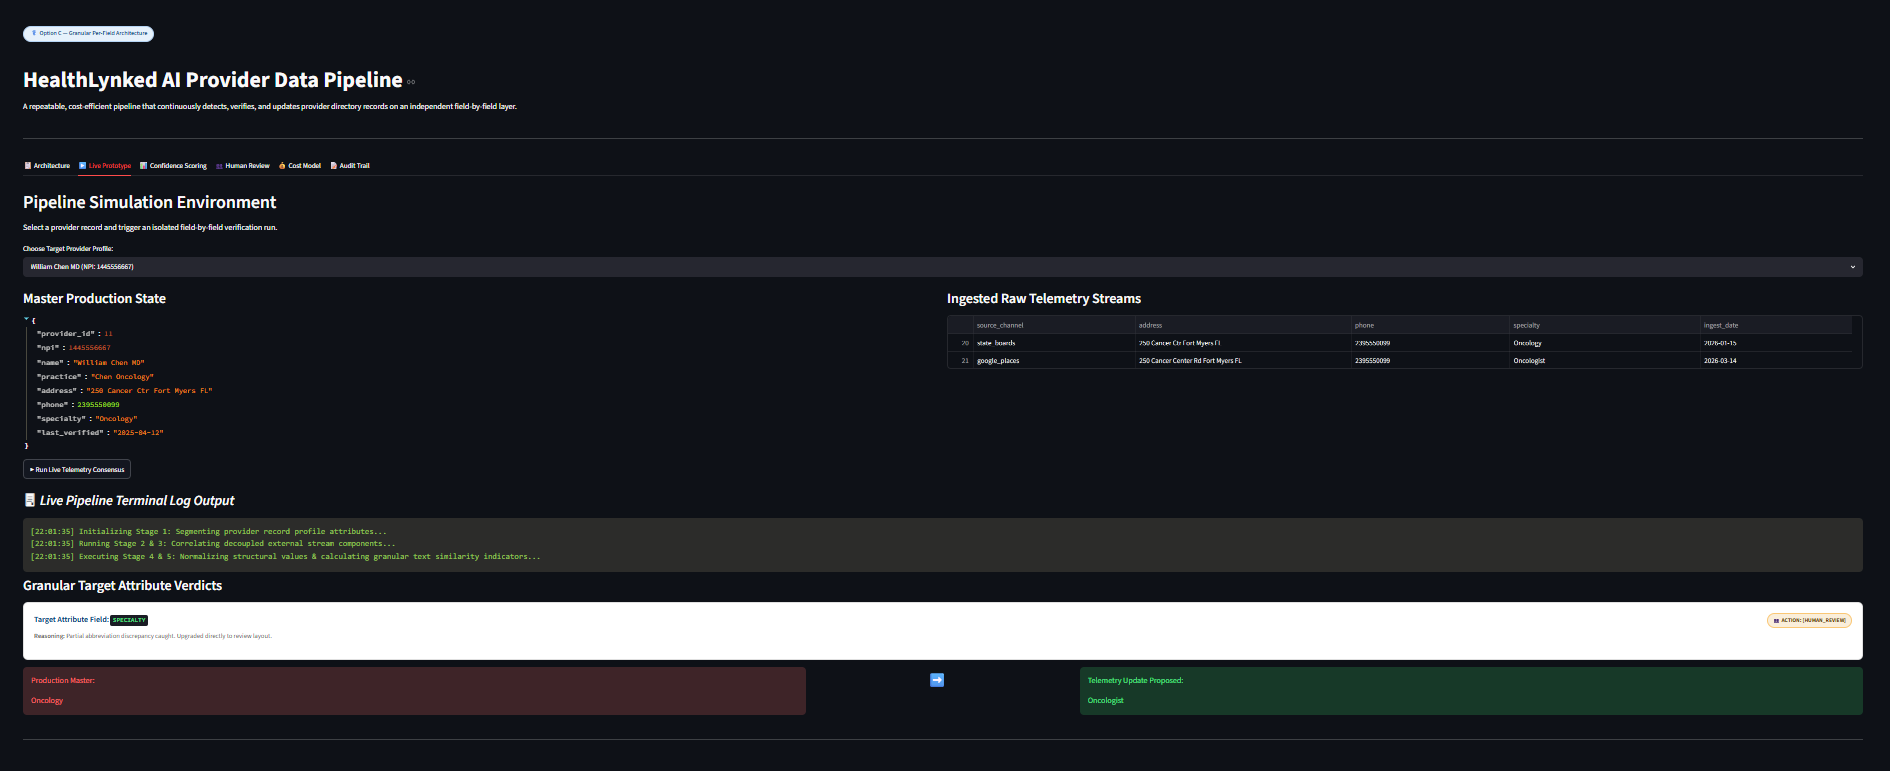

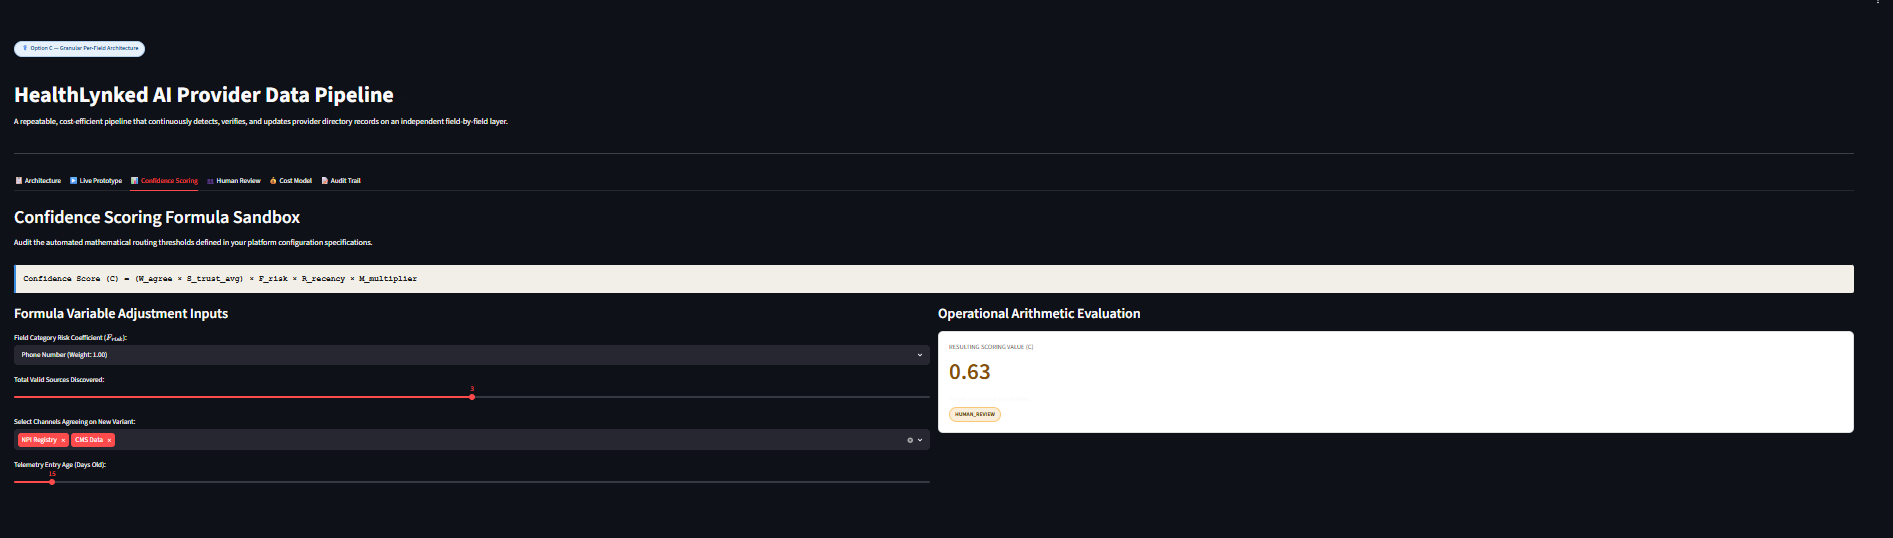

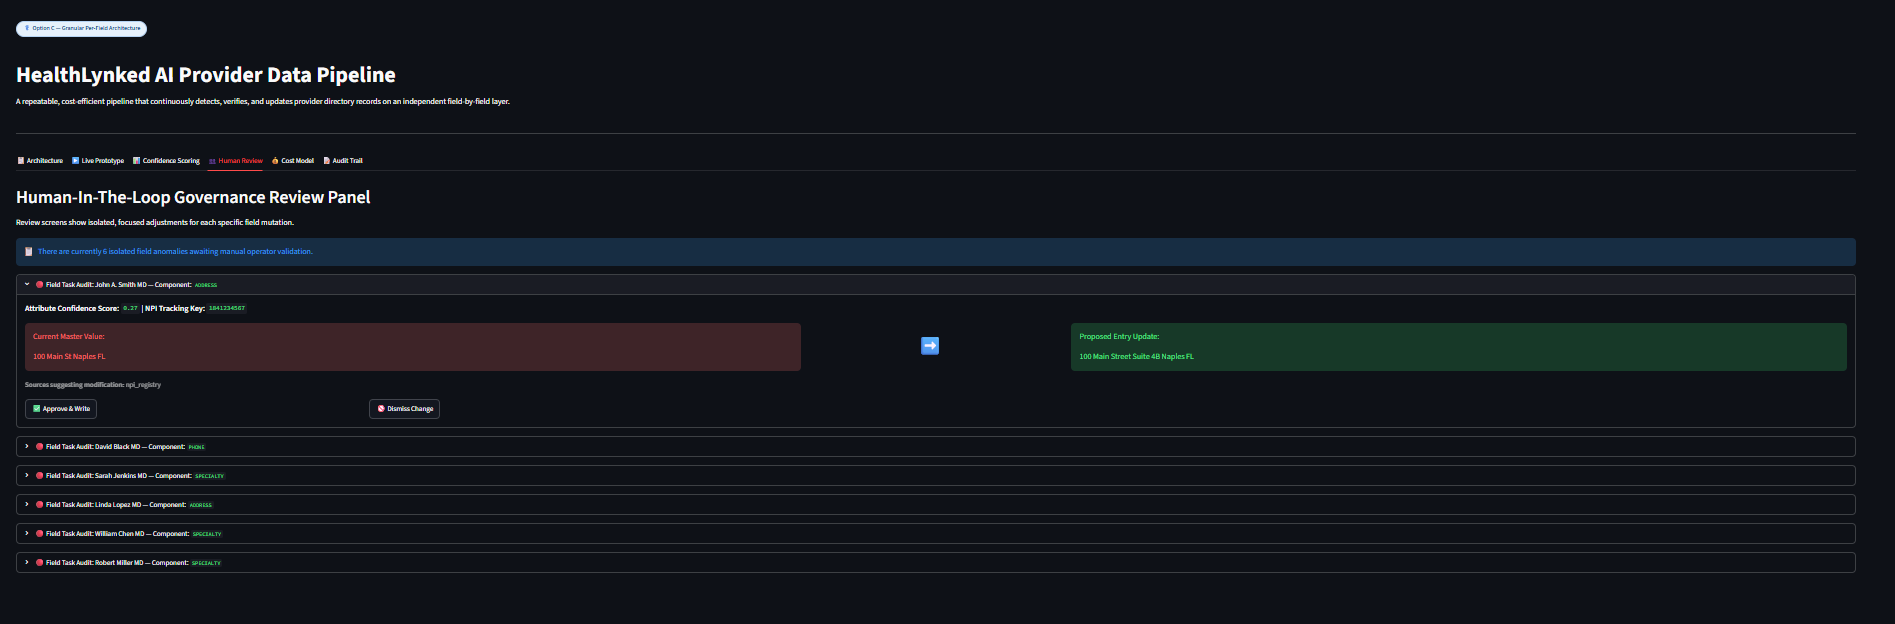

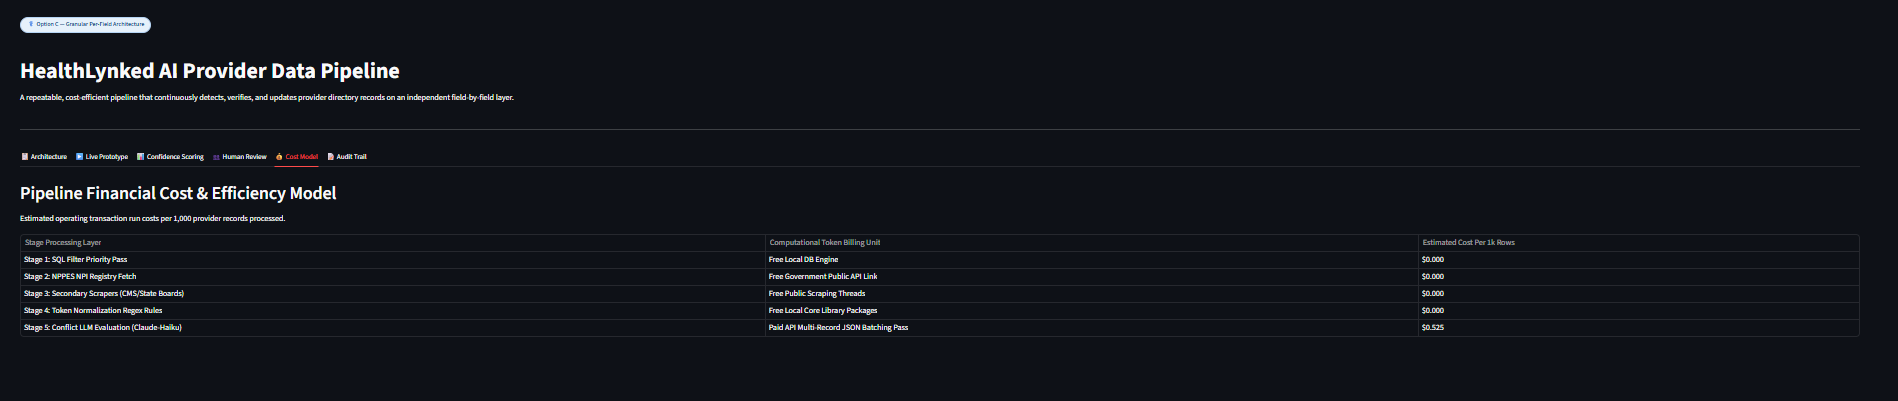

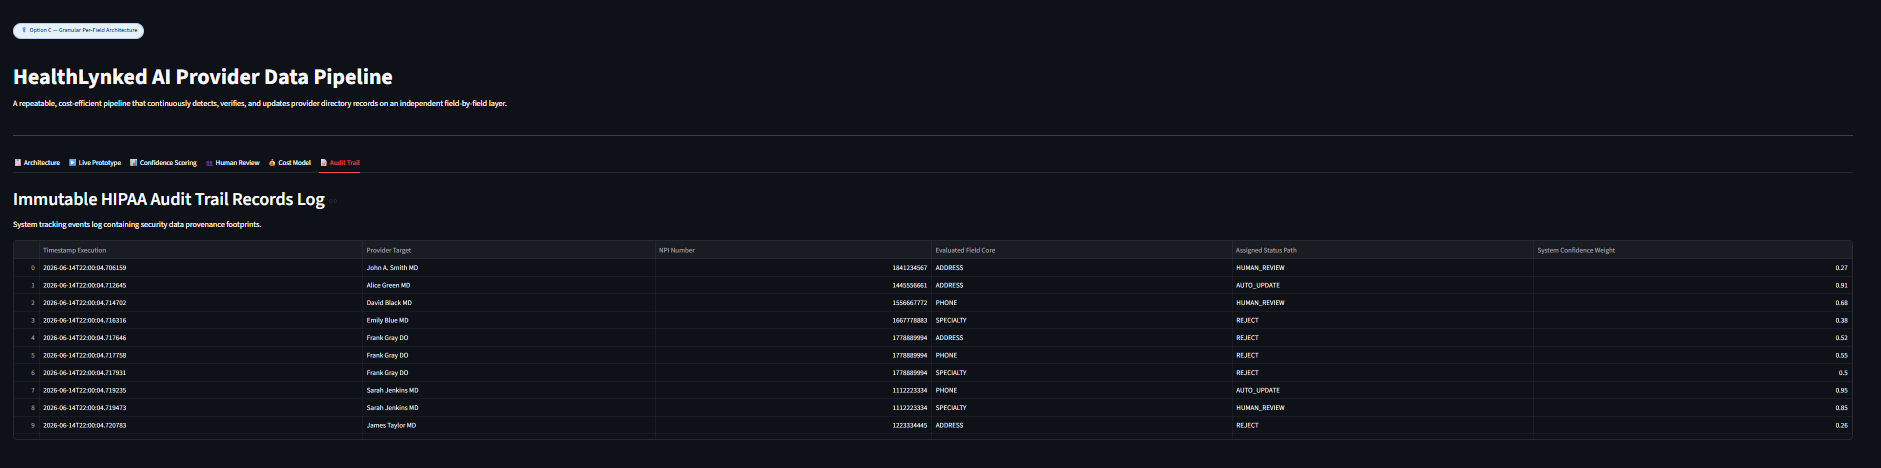